'''
    =================================================
    Milestone 3

    Nama  : Hiro Kevin
    Batch : CODA-018-RMT

   Program ini dibuat untuk melakukan automatisasi data pipeline (ETL) dengan menggunakan PySpark, Airflow, dan MongoDB. Adapun dataset yang dipakai adalah dataset mengenai daftar penjualan fashion di amerika.
    =================================================
    '''
    ```

google slides : https://docs.google.com/presentation/d/16excc6pQSEquEyeAndgCd2ggH0hziMViijnbwGeH0FY/edit?slide=id.g3f26964fd18_0_2450#slide=id.g3f26964fd18_0_2450

# Import library

In [121]:
!pip install kagglehub

In [122]:
!pip install great-expectations

In [123]:
import kagglehub
import os
import shutil

DATASET_ROOT_DIR = "data"

# Download dataset
path = kagglehub.dataset_download("iamsouravbanerjee/customer-shopping-trends-dataset")

print("Dataset downloaded to:", path)

# untuk  membuat folder data 
os.makedirs(DATASET_ROOT_DIR, exist_ok=True)

# Copy seluruh file dari folder dataset ke folder data
for file_name in os.listdir(path):
    source = os.path.join(path, file_name)
    destination = os.path.join(DATASET_ROOT_DIR, file_name)

    if os.path.isfile(source):
        shutil.copy2(source, destination)
    elif os.path.isdir(source):
        shutil.copytree(source, destination, dirs_exist_ok=True)

print("Files copied to:", DATASET_ROOT_DIR)

Dataset downloaded to: C:\Users\hiro\.cache\kagglehub\datasets\iamsouravbanerjee\customer-shopping-trends-dataset\versions\2
Files copied to: data


In [124]:
import pandas as pd
df = pd.read_csv('data/P2M3_hiro_kevin_data_raw.csv')

# EDA 

In [125]:
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,NaN,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3897,3896,forty,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3898,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3899,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3900,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3902 entries, 0 to 3901
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3902 non-null   int64  
 1   Age                     3896 non-null   object 
 2   Gender                  3902 non-null   object 
 3   Item Purchased          3902 non-null   object 
 4   Category                3902 non-null   object 
 5   Purchase Amount (USD)   3902 non-null   int64  
 6   Location                3899 non-null   object 
 7   Size                    3902 non-null   object 
 8   Color                   3902 non-null   object 
 9   Season                  3902 non-null   object 
 10  Review Rating           3895 non-null   float64
 11  Subscription Status     3902 non-null   object 
 12  Shipping Type           3902 non-null   object 
 13  Discount Applied        3902 non-null   object 
 14  Promo Code Used         3902 non-null   

In [127]:
df.isnull().sum()

Customer ID               0
Age                       6
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  3
Size                      0
Color                     0
Season                    0
Review Rating             7
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    4
dtype: int64

In [128]:
df['Age'].value_counts()

Age
69       88
57       87
41       85
25       84
49       84
62       83
50       83
27       83
54       82
32       82
19       81
58       81
42       80
31       79
43       79
28       79
37       78
29       76
46       76
68       75
63       75
56       74
59       74
36       74
55       73
52       73
64       73
35       72
51       72
65       72
45       72
23       71
66       71
30       71
47       71
40       71
53       70
38       70
34       69
18       69
21       69
24       68
48       68
39       68
26       68
70       67
22       66
60       65
61       64
33       63
20       62
67       54
44       51
forty     1
Name: count, dtype: int64

In [129]:
# cek data duplikat
df.duplicated().sum()   

np.int64(2)

In [130]:
# Identifikasi kolom numerik
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Kolom numerik:', numeric_cols)

# Cek outlier dengan metode IQR
def check_outliers_iqr(data, columns):

    outlier_summary = {}
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        outlier_summary[col] = {
            'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
            'lower_bound': lower_bound, 'upper_bound': upper_bound,
            'num_outliers': len(outliers)
        }
        print(f'{col}: Q1={Q1}, Q3={Q3}, IQR={IQR}, Bounds=[{lower_bound}, {upper_bound}], Outliers={len(outliers)}')
    return outlier_summary

outlier_summary = check_outliers_iqr(df, numeric_cols)

Kolom numerik: ['Customer ID', 'Purchase Amount (USD)', 'Review Rating']
Customer ID: Q1=976.25, Q3=2924.75, IQR=1948.5, Bounds=[-1946.5, 5847.5], Outliers=0
Purchase Amount (USD): Q1=39.0, Q3=81.0, IQR=42.0, Bounds=[-24.0, 144.0], Outliers=0
Review Rating: Q1=3.1, Q3=4.4, IQR=1.3000000000000003, Bounds=[1.1499999999999997, 6.3500000000000005], Outliers=0


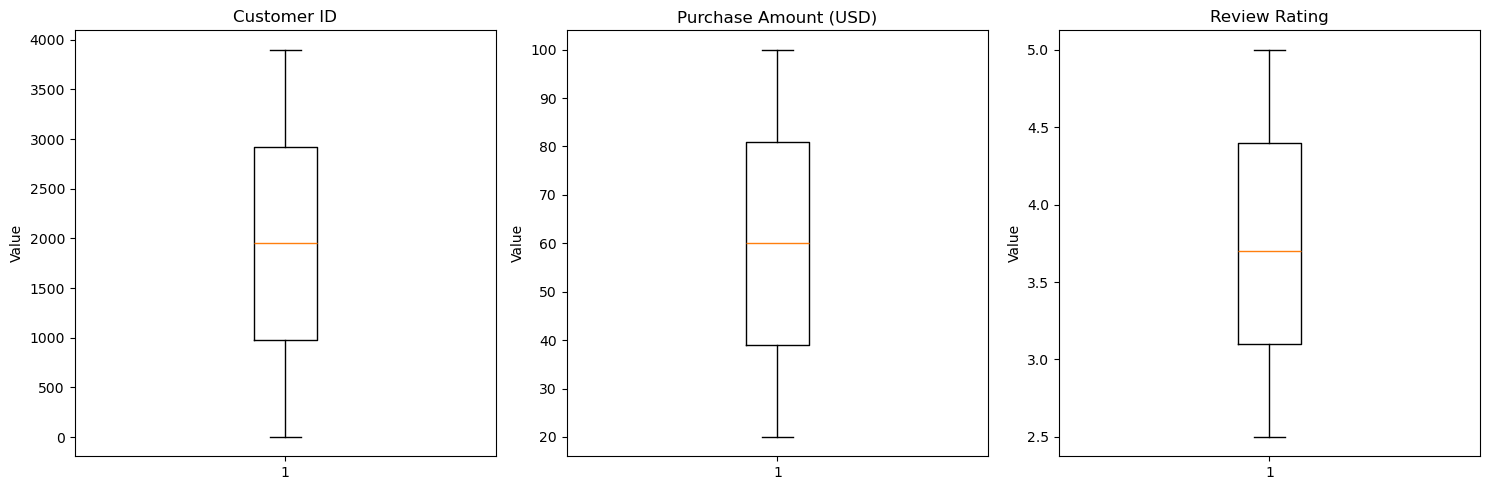

In [131]:
import matplotlib.pyplot as plt

# Boxplot semua kolom numerik
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5*len(numeric_cols), 5))
if len(numeric_cols) == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

# DATA ADJUSTMENT

In [132]:
df = df.dropna(subset=['Age', 'Location', 'Review Rating', 'Frequency of Purchases']) #untuk menghapus baris yang nilainya kosong

In [133]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [134]:
df['Age'] = df['Age'].replace('forty',40) #mengganti nilai 'forty' menjadi 40 pada kolom Age    

In [135]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce') #untuk mengubah tipe data pada kolom Age menjadi numerik

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3883 entries, 1 to 3901
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3883 non-null   int64  
 1   Age                     3883 non-null   int64  
 2   Gender                  3883 non-null   object 
 3   Item Purchased          3883 non-null   object 
 4   Category                3883 non-null   object 
 5   Purchase Amount (USD)   3883 non-null   int64  
 6   Location                3883 non-null   object 
 7   Size                    3883 non-null   object 
 8   Color                   3883 non-null   object 
 9   Season                  3883 non-null   object 
 10  Review Rating           3883 non-null   float64
 11  Subscription Status     3883 non-null   object 
 12  Shipping Type           3883 non-null   object 
 13  Discount Applied        3883 non-null   object 
 14  Promo Code Used         3883 non-null   objec

In [137]:
df['Previous Purchases'] = pd.to_numeric(df['Previous Purchases'], errors='coerce') #untuk mengubah tipe data pada kolom Previous Purchases menjadi numerik

In [138]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        1
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [139]:
df = df.dropna(subset=['Previous Purchases']) #untuk menghapus baris yang nilainya kosong

In [140]:
df['Previous Purchases'] = df['Previous Purchases'].astype(int) #untuk mengubah tipe data pada kolom Previous Purchases menjadi integer

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3882 entries, 1 to 3901
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3882 non-null   int64  
 1   Age                     3882 non-null   int64  
 2   Gender                  3882 non-null   object 
 3   Item Purchased          3882 non-null   object 
 4   Category                3882 non-null   object 
 5   Purchase Amount (USD)   3882 non-null   int64  
 6   Location                3882 non-null   object 
 7   Size                    3882 non-null   object 
 8   Color                   3882 non-null   object 
 9   Season                  3882 non-null   object 
 10  Review Rating           3882 non-null   float64
 11  Subscription Status     3882 non-null   object 
 12  Shipping Type           3882 non-null   object 
 13  Discount Applied        3882 non-null   object 
 14  Promo Code Used         3882 non-null   objec

In [142]:
# untuk menghapus data duplikat
df = df.drop_duplicates()

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3880 entries, 1 to 3901
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3880 non-null   int64  
 1   Age                     3880 non-null   int64  
 2   Gender                  3880 non-null   object 
 3   Item Purchased          3880 non-null   object 
 4   Category                3880 non-null   object 
 5   Purchase Amount (USD)   3880 non-null   int64  
 6   Location                3880 non-null   object 
 7   Size                    3880 non-null   object 
 8   Color                   3880 non-null   object 
 9   Season                  3880 non-null   object 
 10  Review Rating           3880 non-null   float64
 11  Subscription Status     3880 non-null   object 
 12  Shipping Type           3880 non-null   object 
 13  Discount Applied        3880 non-null   object 
 14  Promo Code Used         3880 non-null   objec

In [144]:
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,Yes,14,Venmo,Weekly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3897,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3898,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3899,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3900,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [145]:
# Identifikasi kolom numerik
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Kolom numerik:', numeric_cols)

# Cek outlier dengan metode IQR
def check_outliers_iqr(data, columns):

    outlier_summary = {}
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        outlier_summary[col] = {
            'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
            'lower_bound': lower_bound, 'upper_bound': upper_bound,
            'num_outliers': len(outliers)
        }
        print(f'{col}: Q1={Q1}, Q3={Q3}, IQR={IQR}, Bounds=[{lower_bound}, {upper_bound}], Outliers={len(outliers)}')
    return outlier_summary

outlier_summary = check_outliers_iqr(df, numeric_cols)

Kolom numerik: ['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
Customer ID: Q1=978.75, Q3=2921.25, IQR=1942.5, Bounds=[-1935.0, 5835.0], Outliers=0
Age: Q1=31.0, Q3=57.0, IQR=26.0, Bounds=[-8.0, 96.0], Outliers=0
Purchase Amount (USD): Q1=39.0, Q3=81.0, IQR=42.0, Bounds=[-24.0, 144.0], Outliers=0
Review Rating: Q1=3.1, Q3=4.4, IQR=1.3000000000000003, Bounds=[1.1499999999999997, 6.3500000000000005], Outliers=0
Previous Purchases: Q1=13.0, Q3=38.0, IQR=25.0, Bounds=[-24.5, 75.5], Outliers=0


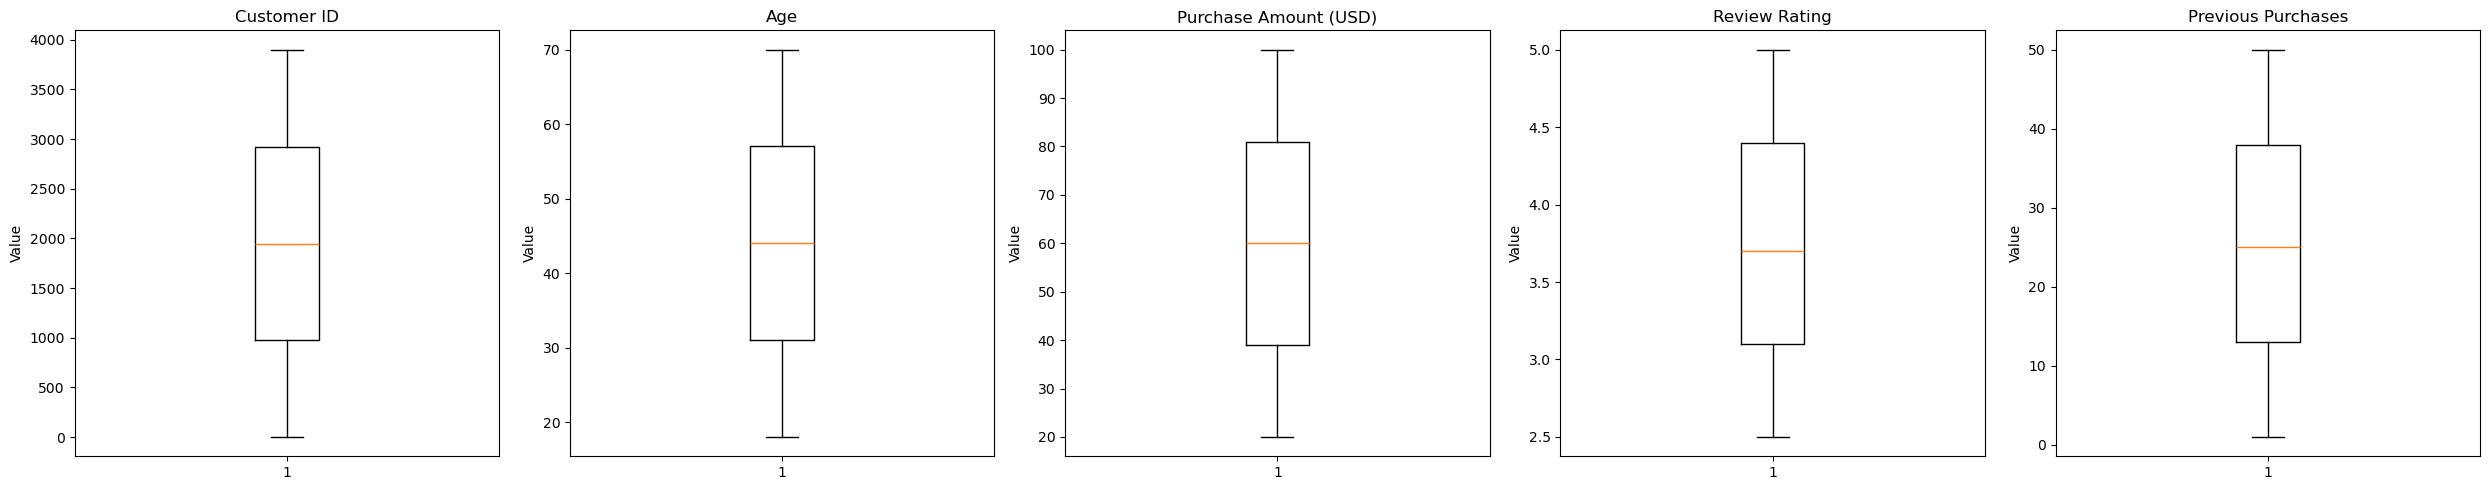

In [146]:
import matplotlib.pyplot as plt

# Boxplot semua kolom numerik
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5*len(numeric_cols), 5))
if len(numeric_cols) == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

# DATA VALIDATION 

In [147]:
import great_expectations as gx

print("Great Expectations version:", gx.__version__)

Great Expectations version: 1.18.1


In [148]:
context = gx.get_context()


In [149]:
# Tambahkan data source
try:
    data_source = context.data_sources.get("pandas_source")
except:
    data_source = context.data_sources.add_pandas("pandas_source")

# Tambahkan data asset
try:
    data_asset = data_source.get_asset("shopping_trends")
except:
    data_asset = data_source.add_csv_asset(
        name="shopping_trends",
        filepath_or_buffer="data/shopping_trends_updated.csv"
    )

# Buat batch request
batch_request = data_asset.build_batch_request()

# Buat validator
validator = context.get_validator(batch_request=batch_request)

In [150]:
validator.head()

Calculating Metrics:   0%|          | 0/1 [00:00<?, ?it/s]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## Expectations

### 1. To be unique

In [151]:
# skenario : Customer id harus unik
validator.expect_column_values_to_be_unique('Customer ID')

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

{
  "success": true,
  "expectation_config": {
    "type": "expect_column_values_to_be_unique",
    "kwargs": {
      "batch_id": "pandas_source-shopping_trends",
      "column": "Customer ID"
    },
    "meta": {},
    "severity": "critical"
  },
  "result": {
    "element_count": 3900,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "partial_unexpected_list": [],
    "missing_count": 0,
    "missing_percent": 0.0,
    "unexpected_percent_total": 0.0,
    "unexpected_percent_nonmissing": 0.0
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

### 2.To be between min_value and max_value

In [152]:
# Skenario : Total pembelian berada dalam range $18-$100
validator.expect_column_values_to_be_between(column='Purchase Amount (USD)', min_value=18, max_value=100)

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

{
  "success": true,
  "expectation_config": {
    "type": "expect_column_values_to_be_between",
    "kwargs": {
      "batch_id": "pandas_source-shopping_trends",
      "column": "Purchase Amount (USD)",
      "min_value": 18.0,
      "max_value": 100.0
    },
    "meta": {},
    "severity": "critical"
  },
  "result": {
    "element_count": 3900,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "partial_unexpected_list": [],
    "missing_count": 0,
    "missing_percent": 0.0,
    "unexpected_percent_total": 0.0,
    "unexpected_percent_nonmissing": 0.0
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

### 3. To be in set

In [153]:
# Skenario : Gender berupa 'Male' atau 'Female'
validator.expect_column_values_to_be_in_set('Gender', ['Male', 'Female'])

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

{
  "success": true,
  "expectation_config": {
    "type": "expect_column_values_to_be_in_set",
    "kwargs": {
      "batch_id": "pandas_source-shopping_trends",
      "column": "Gender",
      "value_set": [
        "Male",
        "Female"
      ]
    },
    "meta": {},
    "severity": "critical"
  },
  "result": {
    "element_count": 3900,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "partial_unexpected_list": [],
    "missing_count": 0,
    "missing_percent": 0.0,
    "unexpected_percent_total": 0.0,
    "unexpected_percent_nonmissing": 0.0
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

### 4. To be in type list

In [154]:
# Skenario : Review rating berupa integer atau float
validator.expect_column_values_to_be_in_type_list('Review Rating', ['integer', 'float'])

Calculating Metrics:   0%|          | 0/1 [00:00<?, ?it/s]

{
  "success": true,
  "expectation_config": {
    "type": "expect_column_values_to_be_in_type_list",
    "kwargs": {
      "batch_id": "pandas_source-shopping_trends",
      "column": "Review Rating",
      "type_list": [
        "integer",
        "float"
      ]
    },
    "meta": {},
    "severity": "critical"
  },
  "result": {
    "observed_value": "float64"
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

### 5. Not to be null

In [155]:
#skenario: Kolom 'Item Purchased' tidak boleh null
validator.expect_column_values_to_not_be_null(column="Item Purchased")

Calculating Metrics:   0%|          | 0/6 [00:00<?, ?it/s]

{
  "success": true,
  "expectation_config": {
    "type": "expect_column_values_to_not_be_null",
    "kwargs": {
      "batch_id": "pandas_source-shopping_trends",
      "column": "Item Purchased"
    },
    "meta": {},
    "severity": "critical"
  },
  "result": {
    "element_count": 3900,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "partial_unexpected_list": []
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

### 6. To match regex

In [156]:
# Skenario: Discount Applied harus berformat 'Yes' atau 'No'.
validator.expect_column_values_to_match_regex('Discount Applied', r'^(Yes|No)$')

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

{
  "success": true,
  "expectation_config": {
    "type": "expect_column_values_to_match_regex",
    "kwargs": {
      "batch_id": "pandas_source-shopping_trends",
      "column": "Discount Applied",
      "regex": "^(Yes|No)$"
    },
    "meta": {},
    "severity": "critical"
  },
  "result": {
    "element_count": 3900,
    "unexpected_count": 0,
    "unexpected_percent": 0.0,
    "partial_unexpected_list": [],
    "missing_count": 0,
    "missing_percent": 0.0,
    "unexpected_percent_total": 0.0,
    "unexpected_percent_nonmissing": 0.0
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}

### 7. # To be between (mean)

In [157]:
# Skenario: Rata-rata umur customer antara 20-60 tahun.
validator.expect_column_mean_to_be_between('Age', min_value=20, max_value=60)

Calculating Metrics:   0%|          | 0/4 [00:00<?, ?it/s]

{
  "success": true,
  "expectation_config": {
    "type": "expect_column_mean_to_be_between",
    "kwargs": {
      "batch_id": "pandas_source-shopping_trends",
      "column": "Age",
      "min_value": 20.0,
      "max_value": 60.0
    },
    "meta": {},
    "severity": "critical"
  },
  "result": {
    "observed_value": 44.06846153846154
  },
  "meta": {},
  "exception_info": {
    "raised_exception": false,
    "exception_traceback": null,
    "exception_message": null
  }
}